# 02. Meta cells with SEACells

Bolero is trained on **metacells** — small, homogeneous groups of cells pooled into
pseudobulks — rather than sparse single cells. This page takes the
[cell embedding](01_cell_embedding.ipynb) from the previous step, assigns metacells with
**SEACells**, and checks their quality.

## Setup

In [1]:
from warnings import simplefilter

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from bolero.tl.pseudobulk import prepare_multi_level_categorical_groups, run_meta_cells
from bolerodata import DATASETS

simplefilter("ignore")
sc.set_figure_params(figsize=(4, 4), frameon=False)

In [2]:
# --- Configuration ---------------------------------------------------------------
# Reads the embedding written by the previous page from the current directory.
DATASET_NAME = "ChromiumPBMC"

# Metacells are called separately within each "limit group", so cells of different
# broad types are never pooled together.
META_CELL_LIMIT = ["subclass"]
MAX_FRAGMENTS = 3_000_000  # cap total fragments per metacell
META_FOLD = 75  # ~ target number of cells per metacell
MIN_CELLS = 200  # skip / merge groups smaller than this

dataset = DATASETS[DATASET_NAME]

## Step 1 — Load the embedding and define limit groups

`prepare_multi_level_categorical_groups` walks the categorical columns in `META_CELL_LIMIT`
and uses the embedding to merge categories that are too small to stand on their own,
producing one `group` label per cell. Metacells are then built *within* each group.

In [4]:
cell_meta = dataset.make_cell_metadata().dropna(subset=META_CELL_LIMIT)
embedding = pd.read_feather("multivi.latent_embedding.feather")

limit_group, group_to_categories = prepare_multi_level_categorical_groups(
    cell_meta, embedding, META_CELL_LIMIT, min_cell_count=MIN_CELLS
)
group_to_categories

Cell metadata has 45270 cells
Cell embedding has 45270 cells
Intersection index has 45270 cells


{'group0': [('MAIT_cells',)],
 'group1': [('CD16__NK_cells',)],
 'group2': [('CD8__TEM_cell',)],
 'group3': [('CD8__TCM_cell',)],
 'group4': [('Regulatory_T_cells',)],
 'group5': [('CD4__TCM_cell',)],
 'group6': [('CD4__TEM_cell',)],
 'group7': [('Plasma_cells', 'Memory_B_cells', 'Naive_B_cells')],
 'group8': [('HSC_MPP',
   'NK_cells',
   'Classical_monocytes',
   'Non-classical_monocytes',
   'pDC',
   'DC1',
   'DC2')]}

In [11]:
adata = anndata.read_h5ad("adata.multivi.with_coords.h5ad")
adata.obs["group"] = limit_group
adata.obs["group"].value_counts()

group
group8    15793
group5    14263
group3     3553
group2     3519
group7     3295
group1     1988
group6     1520
group4      797
group0      542
Name: count, dtype: int64

## Step 2 — Call metacells

`run_meta_cells` runs SEACells within each group (CPU), splitting very large groups and
enforcing the fragment cap. It returns a per-cell metacell assignment, which we store on the
`AnnData` and to disk.

In [12]:
meta_cell_assign = run_meta_cells(
    adata,
    obsm="X_multivi",
    groupby="group",
    max_fragments=MAX_FRAGMENTS,
    meta_fold=META_FOLD,
    group_size_cutoff=MIN_CELLS,
)
adata.obs["meta_cell"] = meta_cell_assign
meta_cell_assign.to_csv("seacell.assign.csv.gz")
adata.write_h5ad("adata.multivi.with_coords.h5ad")

Calculating meta cells:   0%|          | 0/9 [00:00<?, ?it/s]

Welcome to SEACells!


  0%|          | 0/542 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/542 [00:00<?, ?it/s]

...

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/3644 [00:00<?, ?it/s]

  0%|          | 0/3644 [00:00<?, ?it/s]

Building kernel on X_multivi



Calculating meta cells: 100%|██████████| 9/9 [11:11<00:00, 74.57s/it] 


## Step 3 — Visualize metacells on the UMAP

(np.float64(-7.199898791313172),
 np.float64(19.552545142173766),
 np.float64(-5.840992259979248),
 np.float64(22.14824514389038))

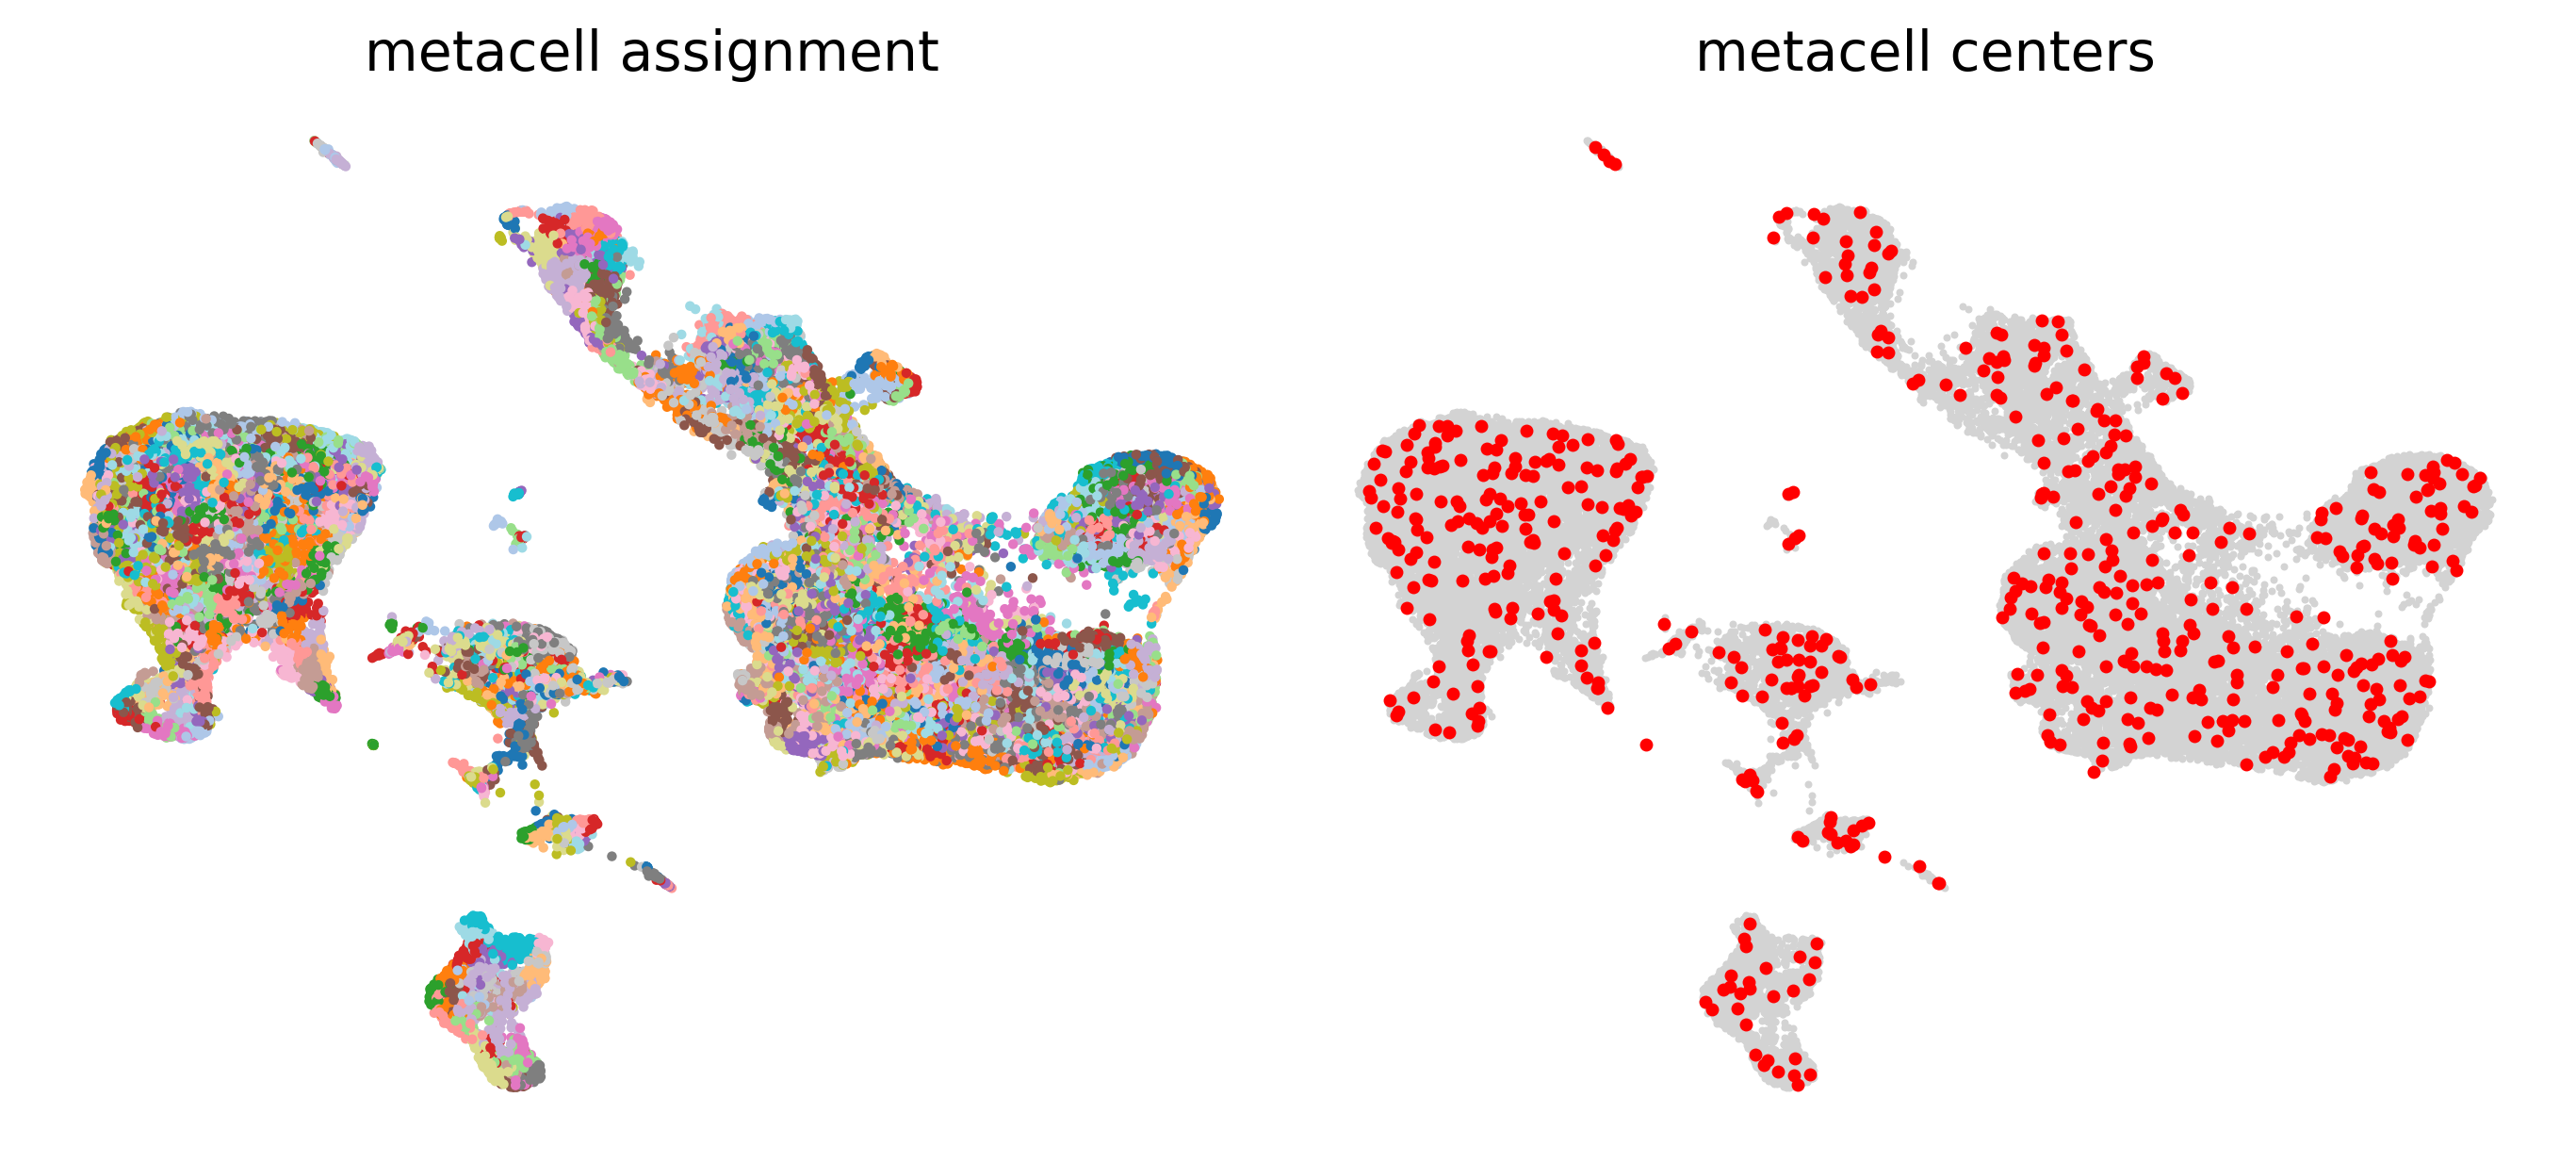

In [13]:
umap = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names, columns=["x", "y"])
codes = adata.obs["meta_cell"].astype("category").cat.codes

fig, axes = plt.subplots(figsize=(9, 4), ncols=2, dpi=150, constrained_layout=True)
axes[0].scatter(umap["x"], umap["y"], s=4, c=codes % 20, cmap="tab20")
axes[0].set_title("metacell assignment")
axes[0].axis("off")

# one representative cell per metacell, in red over a grey background
centers = umap.groupby(adata.obs["meta_cell"], observed=True).sample(1, random_state=0)
axes[1].scatter(umap["x"], umap["y"], s=2, color="lightgrey")
axes[1].scatter(centers["x"], centers["y"], s=8, color="red")
axes[1].set_title("metacell centers")
axes[1].axis("off")

### Metacell coverage

Pooling lifts coverage from single-cell sparsity to usable pseudobulk depth. These histograms
summarize per-metacell fragment / UMI totals and mean quality.

619 metacells from 45270 cells


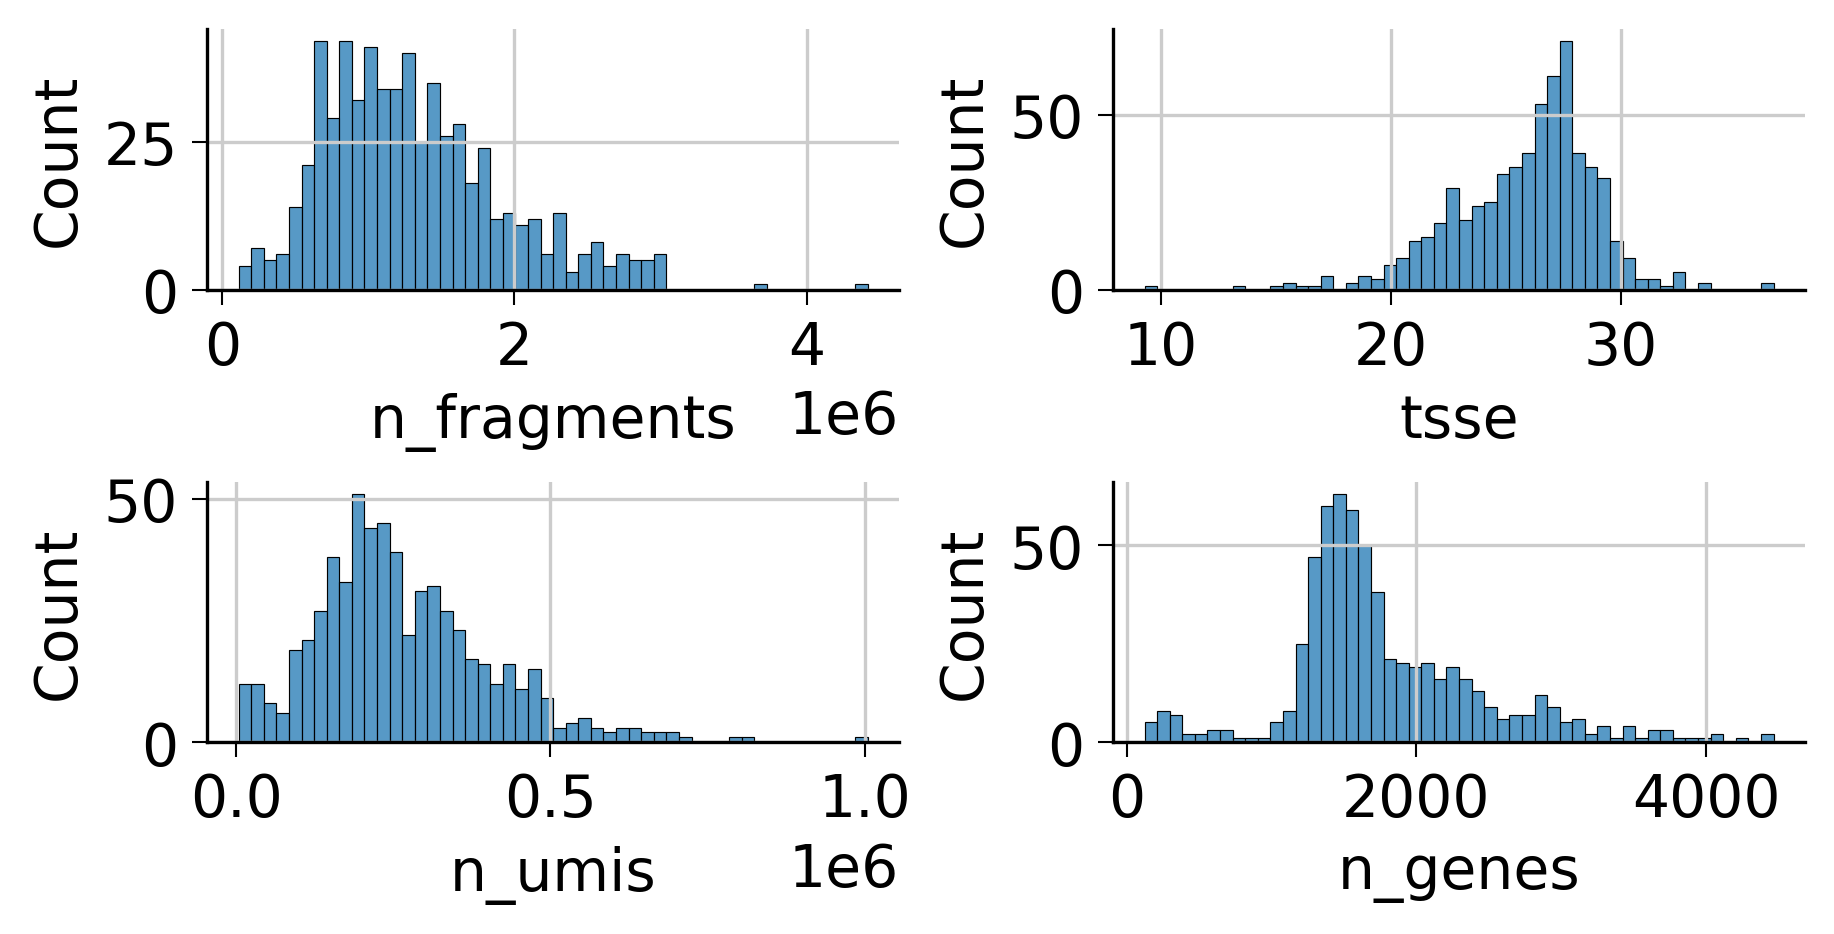

In [14]:
cell_meta = cell_meta.reindex(adata.obs_names)
cell_meta["meta_cell"] = adata.obs["meta_cell"]

n_cell = cell_meta["meta_cell"].notna().sum()
n_meta = cell_meta["meta_cell"].dropna().nunique()
print(f"{n_meta} metacells from {n_cell} cells")

meta_cov = cell_meta.groupby("meta_cell").agg(
    {"n_fragments": "sum", "tsse": "mean", "n_umis": "sum", "n_genes": "mean"}
)
fig, axes = plt.subplots(
    figsize=(6, 3), nrows=2, ncols=2, dpi=150, constrained_layout=True
)
for ax, col in zip(axes.ravel(), meta_cov.columns, strict=False):
    sns.histplot(meta_cov[col], bins=50, ax=ax)

### Metacell purity

A good metacell is dominated by a single category of each variable. For every categorical
metadata column we plot the fraction of each metacell's cells that fall in its majority
category — values near 1 mean clean, homogeneous metacells.

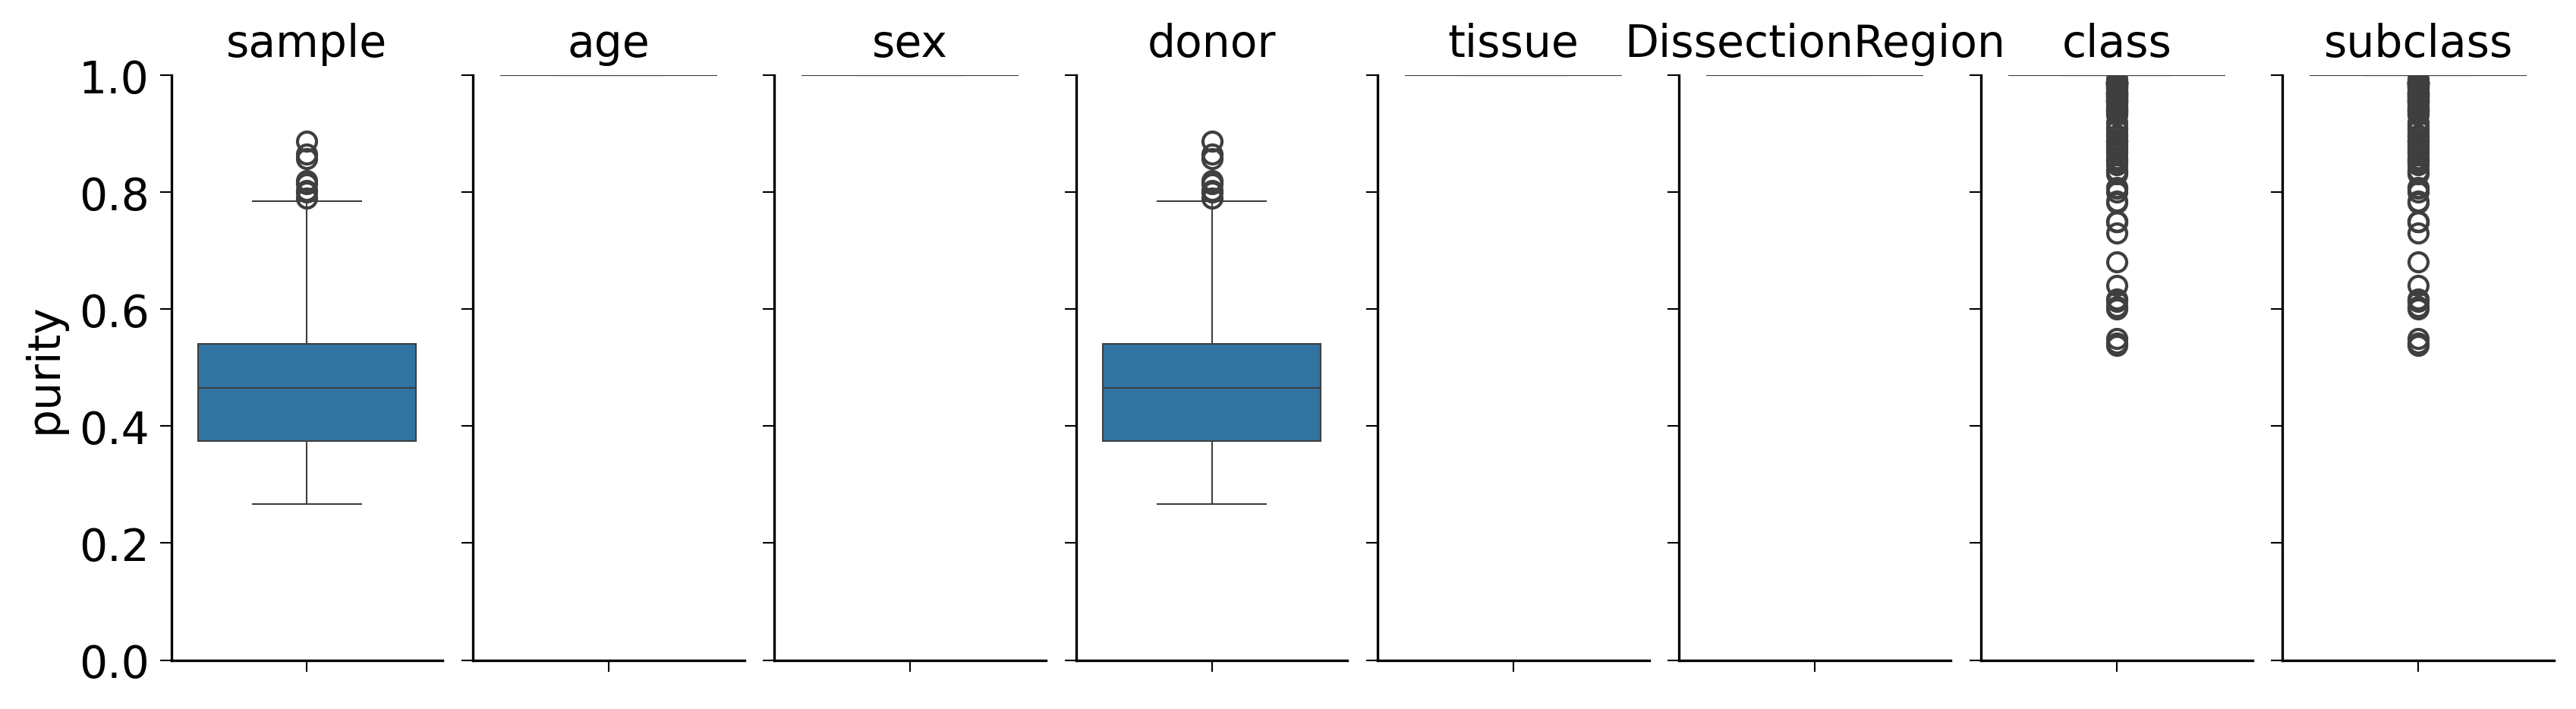

In [15]:
purity = {}
for col, data in cell_meta.items():
    if data.dtype.name != "category" or col == "meta_cell":
        continue
    counts = data.groupby(cell_meta["meta_cell"]).value_counts().unstack()
    frac = counts.div(counts.sum(axis=1), axis=0)
    purity[col] = frac.max(axis=1)
purity = pd.DataFrame(purity)

plot_cols = [
    c
    for c in [
        "sample",
        "age",
        "sex",
        "donor",
        "tissue",
        "DissectionRegion",
        "class",
        "subclass",
    ]
    if c in purity
]
fig, axes = plt.subplots(
    figsize=(1.4 * len(plot_cols), 3),
    ncols=len(plot_cols),
    dpi=150,
    constrained_layout=True,
)
for i, (ax, col) in enumerate(zip(np.atleast_1d(axes), plot_cols, strict=False)):
    sns.boxplot(y=purity[col], ax=ax)
    ax.set(ylim=(0, 1), title=col, xlabel="", ylabel="purity" if i == 0 else "")
    if i:
        ax.set(yticklabels=[])
    ax.grid(axis="y")

---

`seacell.assign.csv.gz` (and the `meta_cell` column on the embedding `AnnData`) now map every
cell to a metacell. These metacells are the units Bolero aggregates into conditioned
pseudobulks for training and inference.